<pre>
<center><b><h1>Bank Marketing Campaign</b></center>
<center><b><h1>Week - 4</b></center>
Name : mehta sneha
Roll number : 455
<pre>    

<pre>
<center><b><h1>Logistic Regression</b></center>
<pre>  

### Step 1. Import the necessary libraries

In [7]:
import pandas as pd
import numpy as np

### Step 2. Assign dataset to a variable called df

In [9]:
df = pd.read_csv('bank-full.csv', sep=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


### Step 3: Separate X and y

In [10]:
X = df.drop('y', axis=1)
y = df['y']

### Step 4: Convert target yes/no into 1/0

In [20]:
y = y.map({'no': 0, 'yes': 1})

### Step 5: Identify numerical and categorical columns

In [21]:
numeric_columns = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [22]:
categorical_columns = X.select_dtypes(
    include=['object']
).columns.tolist()

print("\nCategorical columns:")
print(categorical_columns)


Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### Step 6: Convert categorical columns into numbers

In [23]:
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

In [24]:
X = X.astype(int)

### Step 7: Split the data into training and testing

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Step 8: Scale numerical features

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()

X_train[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

In [29]:
X_train

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
24001,-0.460434,-0.164410,1.582124,-0.457311,-0.246104,-0.410910,-0.241509,0,0,0,...,0,0,0,0,0,0,0,0,0,1
43409,-1.589641,0.899627,-1.298384,2.502493,0.398202,1.446096,2.664584,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20669,0.292371,-0.365486,-0.458236,5.697691,0.398202,-0.410910,-0.241509,0,0,0,...,0,0,0,0,0,0,0,0,0,1
18810,0.668773,-0.445003,1.822166,-0.862499,2.653271,-0.410910,-0.241509,0,0,0,...,1,0,0,0,0,0,0,0,0,1
23130,-0.272233,-0.361249,1.222060,-0.777602,2.331118,-0.410910,-0.241509,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17958,0.856974,-0.146160,1.702145,-0.773743,-0.246104,-0.410910,-0.241509,1,0,0,...,1,0,0,0,0,0,0,0,0,1
15941,-0.460434,-0.437834,0.741975,-0.700423,0.720354,-0.410910,-0.241509,0,0,0,...,1,0,0,0,0,0,0,0,0,1
16952,0.386471,-0.419258,1.102039,-0.619386,-0.568256,-0.410910,-0.241509,1,0,0,...,1,0,0,0,0,0,0,0,0,1
34781,-1.307339,0.388954,-1.178363,-0.121583,-0.568256,-0.410910,-0.241509,0,0,0,...,0,0,0,1,0,0,0,0,0,1


### Step 9:Initialize a Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
model = LogisticRegression(max_iter=1000)

### Step 10:Train the model

In [32]:
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

### Step 11:Predict the data

In [33]:
y_pred = model.predict(X_test)

In [34]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

### Step 12:Check accuracy of model

In [35]:
from sklearn.metrics import accuracy_score

In [36]:
acc = accuracy_score(y_pred,y_test)
print('model accuracy:',acc)

model accuracy: 0.9015813336282207


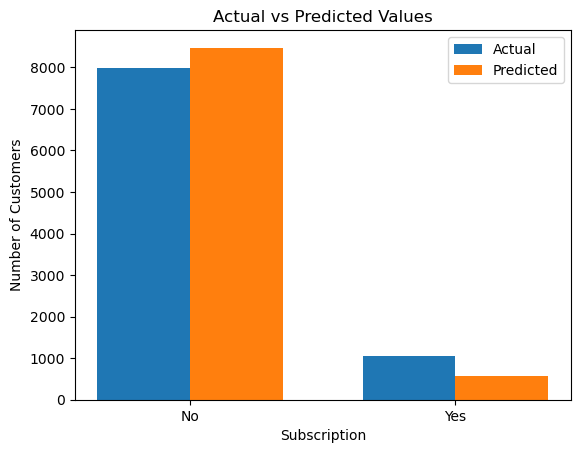

In [37]:
import matplotlib.pyplot as plt
import numpy as np

actual_counts = np.bincount(y_test)
predicted_counts = np.bincount(y_pred)

x = np.array([0, 1])
width = 0.35

plt.bar(x - width/2, actual_counts, width, label='Actual')
plt.bar(x + width/2, predicted_counts, width, label='Predicted')

plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('Subscription')
plt.ylabel('Number of Customers')
plt.title('Actual vs Predicted Values')
plt.legend()

plt.show()

### Step 13:Save Model Using Joblib Library

In [38]:
import joblib 

In [39]:
joblib.dump(model, "model.pkl")

['model.pkl']